In [13]:
import polars as pl
from procompa import get_project_root
from procompa.helpers import clean_identifiers, add_interesting_stoichiometry
from itertools import combinations_with_replacement

PRJ_ROOT = get_project_root()
data_dir = PRJ_ROOT / "data"

load all xlink data (from all 3 papers)

In [14]:
bartolec_xlinks = pl.read_parquet("/cluster/project/beltrao/jjaenes/25.12_pooled-ppi-yeast/data/resources/xlinks/bartolec2019.parquet")
linden_xlinks = pl.read_parquet("/cluster/project/beltrao/jjaenes/25.12_pooled-ppi-yeast/data/resources/xlinks/linden2020.parquet")
klössel_xlinks = pl.read_parquet("/cluster/project/beltrao/jjaenes/25.12_pooled-ppi-yeast/data/resources/xlinks/klössel2024.parquet")

linden_xlinks = linden_xlinks.select(bartolec_xlinks.columns)
klössel_xlinks = klössel_xlinks.select(bartolec_xlinks.columns)
combined_xlink = pl.concat([bartolec_xlinks, linden_xlinks, klössel_xlinks], how="vertical")
combined_xlink.rename({'uniprot_id1':'uniprot_id1_xlink', 'uniprot_id2':'uniprot_id2_xlink'})

uniprot_id1_xlink,uniprot_id2_xlink,pos1,pos2,source
str,str,i64,i64,str
"""P22203""","""P48836""",87,84,"""bartolec2019"""
"""P05737""","""P0CX49""",17,133,"""bartolec2019"""
"""P0CX52""","""P38011""",107,53,"""bartolec2019"""
"""P02293""","""P04912""",50,14,"""bartolec2019"""
"""P04912""","""P61830""",124,126,"""bartolec2019"""
…,…,…,…,…
"""Q99383""","""Q99383""",189,304,"""klössel2024"""
"""Q99383""","""Q99383""",231,316,"""klössel2024"""
"""Q99383""","""Q99383""",231,244,"""klössel2024"""


In [15]:
pdb_mapping = pl.read_csv(data_dir/"complete_complex_pdb_mapping_v2/all_pdb_matches_with_match_class.csv")
Complex_portal_df = pl.read_csv(data_dir/"Complex_Portal/Saccharomyces_cerevisiae_ComplexTab.tsv", separator="\t")


In [16]:
Complex_portal_clean = clean_identifiers(Complex_portal_df.select(["#Complex ac", "Identifiers (and stoichiometry) of molecules in complex"]))
#make pairs (also homdimers)
Complex_portal_clean_pairs = Complex_portal_clean.with_columns(
    pl.col("Cleaned Identifiers")
    .str.split(" ")
    .map_elements(
        lambda ids: list(combinations_with_replacement(sorted(ids), 2)),
        return_dtype=pl.List(pl.List(pl.String)),
    )
    .alias("pairs")
).explode("pairs").with_columns(
    pl.col("pairs").list.get(0).alias("protein1"),
    pl.col("pairs").list.get(1).alias("protein2"),
).drop("pairs")

In [17]:
# Canonicalize crosslink pairs (order-independent) and count occurrences
xlink_counts = (
    combined_xlink
    .with_columns(
        pl.min_horizontal("uniprot_id1", "uniprot_id2").alias("protein1"),
        pl.max_horizontal("uniprot_id1", "uniprot_id2").alias("protein2"),
    )
    .group_by("protein1", "protein2")
    .agg(pl.len().alias("n_crosslinks"))
)

# Join onto your pairs df (already canonicalized the same way)
Complex_portal_clean_pairs = Complex_portal_clean_pairs.join(xlink_counts, on=["protein1", "protein2"], how="left").with_columns(
    pl.col("n_crosslinks").fill_null(0)
)

In [18]:
Complex_portal_clean_pairs = Complex_portal_clean_pairs.with_columns(
    pair_type = pl.when(pl.col("protein1") == pl.col("protein2")).then(pl.lit("homodimer")).otherwise(pl.lit("heterodimer"))
)

In [19]:
crosslink_summary = (
    Complex_portal_clean_pairs
    .group_by("#Complex ac", "pair_type")
    .agg(pl.col("n_crosslinks").sum())
    .pivot(on="pair_type", index="#Complex ac", values="n_crosslinks")
    .rename({"heterodimer": "n_inter_crosslink", "homodimer": "n_intra_crosslink"})
    .with_columns(
        pl.col("n_inter_crosslink").fill_null(0),
        pl.col("n_intra_crosslink").fill_null(0),
    )
)

#Complex_portal_clean_pairs = Complex_portal_clean_pairs.join(crosslink_summary, on="complex_ac", how="left")

In [20]:
pdb_crosslink = pdb_mapping.join(
    crosslink_summary, left_on="complex_ac", right_on="#Complex ac", how="left"
).with_columns(
    pl.col("n_inter_crosslink").fill_null(0),
    pl.col("n_intra_crosslink").fill_null(0),
)

add wheterh stoi is intrestinh

In [21]:
Complex_portal_stoi = add_interesting_stoichiometry(Complex_portal_clean,column = 'Identifiers (and stoichiometry) of molecules in complex', check_stoichiometry_given = True)
Complex_portal_stoi = Complex_portal_stoi.select(['#Complex ac','interesting_stoichiometry','stoichiometry_given'])

In [22]:
pdb_crosslink = pdb_crosslink.join(
    Complex_portal_stoi, left_on="complex_ac", right_on="#Complex ac", how="left"
).with_columns(
    pl.col("stoichiometry_given").fill_null(False) #(e.g for CPX-1556)
)



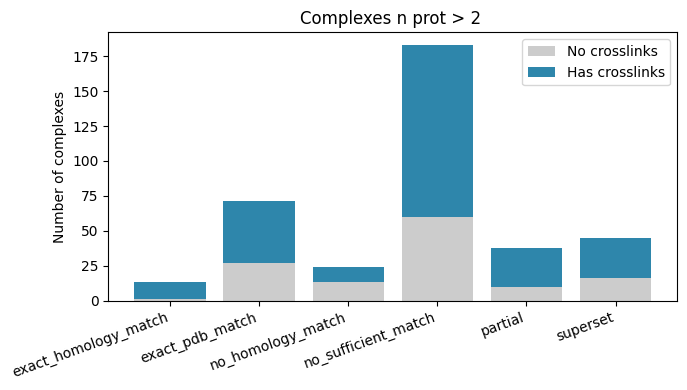

In [29]:
import matplotlib.pyplot as plt

summary = (
    pdb_crosslink
    .filter(pl.col("n_proteins") > 2)
    .with_columns(
        (pl.col("n_inter_crosslink") + pl.col("n_intra_crosslink") > 0).alias("has_xlinks")
    )
    .group_by("match_class", "has_xlinks")
    .agg(pl.len().alias("n_complexes"))
    .sort("match_class")
)

pivot = summary.pivot(on="has_xlinks", index="match_class", values="n_complexes").fill_null(0)
pivot = pivot.rename({"true": "has_crosslinks", "false": "no_crosslinks"})

fig, ax = plt.subplots(figsize=(7, 4))
classes = pivot["match_class"].to_list()
x = range(len(classes))
ax.bar(x, pivot["no_crosslinks"], label="No crosslinks", color="#cccccc")
ax.bar(x, pivot["has_crosslinks"], bottom=pivot["no_crosslinks"], label="Has crosslinks", color="#2E86AB")
ax.set_xticks(x)
ax.set_xticklabels(classes, rotation=20, ha="right")
ax.set_ylabel("Number of complexes")
ax.set_title("Complexes n prot > 2 ")
ax.legend()
plt.tight_layout()
#plt.savefig("match_class_crosslinks.png", dpi=200)

In [50]:
table = (
    pdb_crosslink
    .filter(pl.col("n_proteins") > 2)
    .with_columns(
        (pl.col("n_inter_crosslink") + pl.col("n_intra_crosslink") > 0).alias("has_xlinks")
    )
    .group_by("match_class")
    .agg(
        pl.len().alias("n_complexes"),
        pl.col("has_xlinks").sum().alias("n_with_crosslinks"),
    )
    .sort("match_class")
)

total_row = table.select(
    pl.lit("Total").alias("match_class"),
    pl.col("n_complexes").sum(),
    pl.col("n_with_crosslinks").sum(),
)

table = pl.concat([table, total_row])

print(table)

shape: (7, 3)
┌──────────────────────┬─────────────┬───────────────────┐
│ match_class          ┆ n_complexes ┆ n_with_crosslinks │
│ ---                  ┆ ---         ┆ ---               │
│ str                  ┆ u32         ┆ u32               │
╞══════════════════════╪═════════════╪═══════════════════╡
│ exact_homology_match ┆ 13          ┆ 12                │
│ exact_pdb_match      ┆ 71          ┆ 44                │
│ no_homology_match    ┆ 24          ┆ 11                │
│ no_sufficient_match  ┆ 183         ┆ 123               │
│ partial              ┆ 38          ┆ 28                │
│ superset             ┆ 45          ┆ 29                │
│ Total                ┆ 374         ┆ 247               │
└──────────────────────┴─────────────┴───────────────────┘


In [43]:
def summarize(name, filtered_df):
    return filtered_df.with_columns(
        (pl.col("n_inter_crosslink") + pl.col("n_intra_crosslink") > 0).alias("has_xlinks"),
        (pl.col("n_inter_crosslink") > 0).alias("has_inter_xlinks"),
        (pl.col("n_intra_crosslink") > 0).alias("has_intra_xlinks"),
    ).select(
        pl.lit(name).alias("subset"),
        pl.len().alias("n_complexes"),
        pl.col("has_xlinks").sum().alias("n_with_crosslinks"),
        pl.col("has_inter_xlinks").sum().alias("n_with_inter_crosslinks"),
        pl.col("has_intra_xlinks").sum().alias("n_with_intra_crosslinks"),
    )

base = pdb_crosslink.filter(pl.col("match_class") == "no_homology_match")

table = pl.concat([
    summarize("no homology match", base),
    summarize("n proteins > 2", base.filter(pl.col("n_proteins") > 2)),
    summarize( "inter. stoi.",
        base.filter((pl.col("n_proteins") > 2) & pl.col("interesting_stoichiometry"))
    ),
])

print(table)

shape: (3, 5)
┌───────────────────┬─────────────┬───────────────────┬──────────────────────┬─────────────────────┐
│ subset            ┆ n_complexes ┆ n_with_crosslinks ┆ n_with_inter_crossli ┆ n_with_intra_crossl │
│ ---               ┆ ---         ┆ ---               ┆ nks                  ┆ inks                │
│ str               ┆ u32         ┆ u32               ┆ ---                  ┆ ---                 │
│                   ┆             ┆                   ┆ u32                  ┆ u32                 │
╞═══════════════════╪═════════════╪═══════════════════╪══════════════════════╪═════════════════════╡
│ no homology match ┆ 70          ┆ 27                ┆ 7                    ┆ 27                  │
│ n proteins > 2    ┆ 24          ┆ 11                ┆ 3                    ┆ 11                  │
│ inter. stoi.      ┆ 3           ┆ 1                 ┆ 0                    ┆ 1                   │
└───────────────────┴─────────────┴───────────────────┴──────────────────────

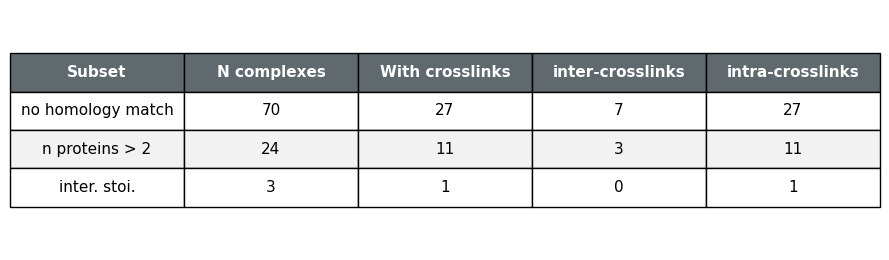

In [45]:
col_labels = ["Subset", "N complexes", "With crosslinks", "inter-crosslinks", "intra-crosslinks"]
cell_text = table.rows()

fig, ax = plt.subplots(figsize=(9, 1.2 + 0.5 * len(cell_text)))
ax.axis("off")

tbl = ax.table(
    cellText=cell_text,
    colLabels=col_labels,
    cellLoc="center",
    loc="center",
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1, 2)

# Style header row
for j in range(len(col_labels)):
    cell = tbl[0, j]
    cell.set_facecolor("#5F696E")
    cell.set_text_props(color="white", weight="bold")

# Zebra-stripe body rows
for i in range(1, len(cell_text) + 1):
    for j in range(len(col_labels)):
        cell = tbl[i, j]
        cell.set_facecolor("#f2f2f2" if i % 2 == 0 else "white")

plt.tight_layout()
#plt.savefig("crosslink_summary_table.png", dpi=300, bbox_inches="tight")

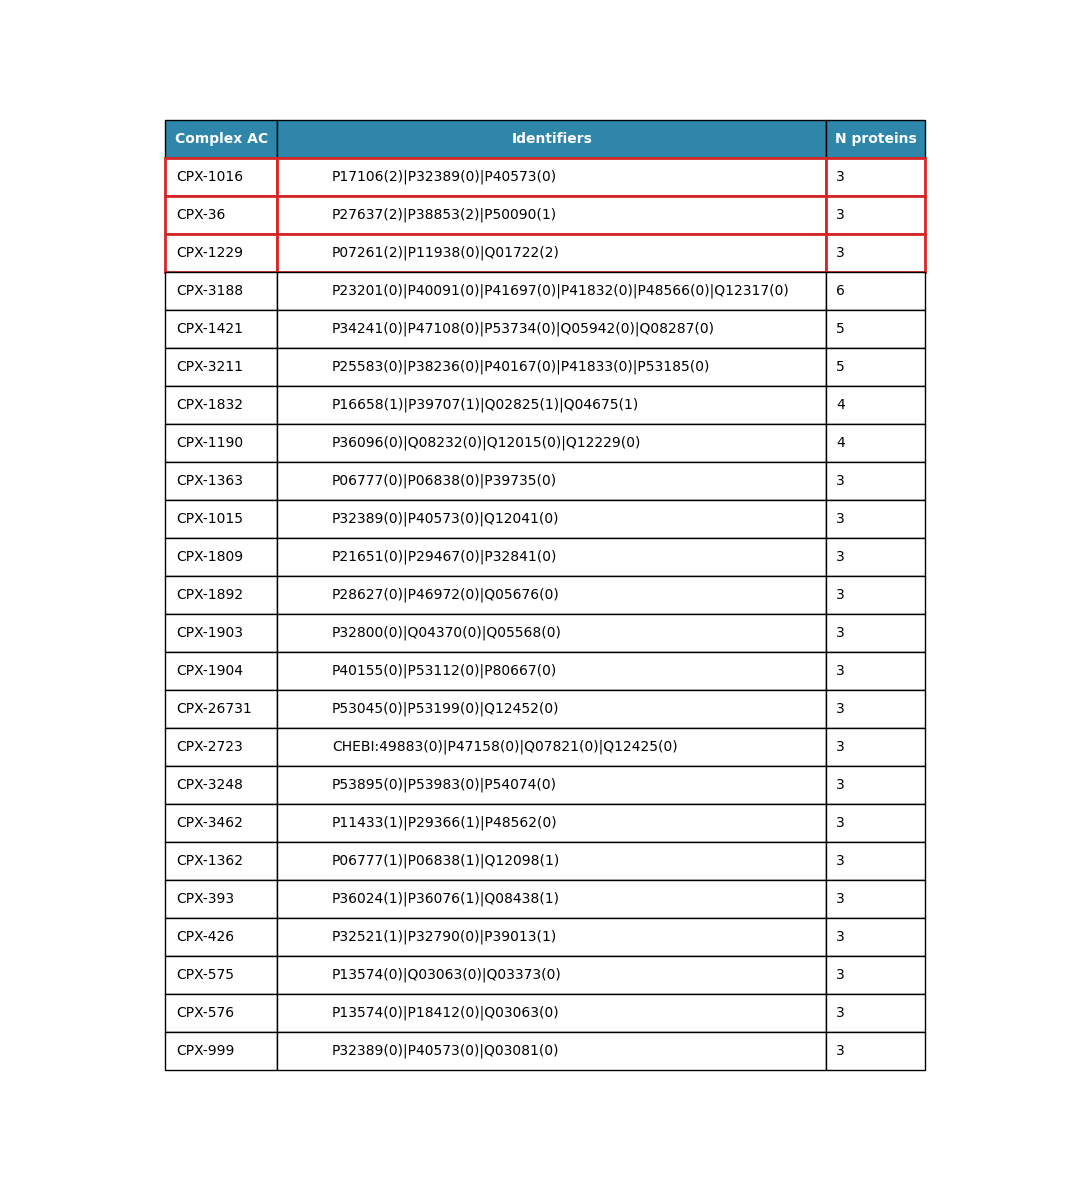

In [48]:
import matplotlib.pyplot as plt

subset = base.filter(pl.col("n_proteins") > 2)

subset_with_ids = subset.join(
    Complex_portal_df.select(["#Complex ac", "Identifiers (and stoichiometry) of molecules in complex"]),
    left_on="complex_ac", right_on="#Complex ac", how="left"
).select(
    "complex_ac",
    pl.col("Identifiers (and stoichiometry) of molecules in complex").alias("identifiers"),
    "n_proteins",
    "interesting_stoichiometry",
).sort(["interesting_stoichiometry", "n_proteins"], descending=[True, True])

# --- Render as PNG table ---------------------------------------------------
col_labels = ["Complex AC", "Identifiers", "N proteins"]
cell_text = subset_with_ids.select("complex_ac", "identifiers", "n_proteins").rows()
highlight_flags = subset_with_ids["interesting_stoichiometry"].to_list()

fig, ax = plt.subplots(figsize=(11, 1.2 + 0.45 * len(cell_text)))
ax.axis("off")

tbl = ax.table(
    cellText=cell_text,
    colLabels=col_labels,
    cellLoc="left",
    loc="center",
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1, 1.8)
tbl.auto_set_column_width(col=list(range(len(col_labels))))

# Style header row
for j in range(len(col_labels)):
    cell = tbl[0, j]
    cell.set_facecolor("#2E86AB")
    cell.set_text_props(color="white", weight="bold")

# Frame (border only) around interesting_stoichiometry rows, plain white otherwise
for i, is_interesting in enumerate(highlight_flags, start=1):
    for j in range(len(col_labels)):
        cell = tbl[i, j]
        cell.set_facecolor("white")
        if is_interesting:
            cell.set_edgecolor("#D62728")
            cell.set_linewidth(2)

plt.tight_layout()
#plt.savefig("no_homology_n_proteins_gt2_table.png", dpi=300, bbox_inches="tight")